# Postprocessing after editing

The purpose of this script is to evalute the post editing (read pivotal tuning) results

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os
import numpy as np
import sys
from pathlib import Path
scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
from gan_pipeline.core import custom_plots as custom_plots
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from postprocessing import PostProcessing
from well_evaluation import WellMismatch
custom_plots.apply_custom_plotting_flavor()

well_data_path = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\well_data\Well_data.xlsx")
real_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\training\setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100\samples\facies\*.npy")

gan_data_dir_1 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th1\realizations\*.npy")
gan_data_dir_2 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th2\realizations\*.npy")
gan_data_dir_3 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th5\realizations\*.npy")
#gan_data_dir_all= Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_all_th\realizations\*.npy")

output_dir_1 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th1")
output_dir_2 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th2")
output_dir_3 = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th5")
#output_dir_all= Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_all_th")


## Inspect Loss history

In [22]:
def plot_combined_histories(dir_paths, labels=None, figsize=(8.27, 4)):
    """
    Plots training loss history for multiple GAN runs on a single plot.
    
    Parameters:
    -----------
    dir_paths : list of Path
        List of paths (can include the wildcard/realizations folder).
    labels : list of str, optional
        Custom names for the legend. If None, folder names are used.
    figsize : tuple, default (8.27, 4)
        The size of the output figure.
    """
    plt.figure(figsize=figsize)
    plt.grid(True)
    
    for i, path in enumerate(dir_paths):
        # Resolve the history directory (stepping up from "realizations/*.npy" if needed)
        if "*" in str(path):
            history_dir = path.parent.parent
        else:
            history_dir = path
            
        try:
            # Locate the first CSV file in the directory
            history_files = list(history_dir.glob("*.csv"))
            if not history_files:
                print(f"Warning: No CSV files found in {history_dir}")
                continue
                
            # Load the loss data
            df_loss = pd.read_csv(history_files[0])
            steps = np.arange(len(df_loss))
            
            # Determine the label for this line
            line_label = labels[i] if labels and i < len(labels) else history_dir.name
            
            # Plot on the active figure
            plt.plot(steps, df_loss['loss'], label=line_label)
            
        except Exception as e:
            print(f"Error processing {history_dir}: {e}")

    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    #plt.title('Discriminator Loss Comparison')
    plt.legend()
    plt.tight_layout()

    plt.savefig("pivotal_tuning_loss.png", dpi=600, bbox_inches='tight')
    plt.show()

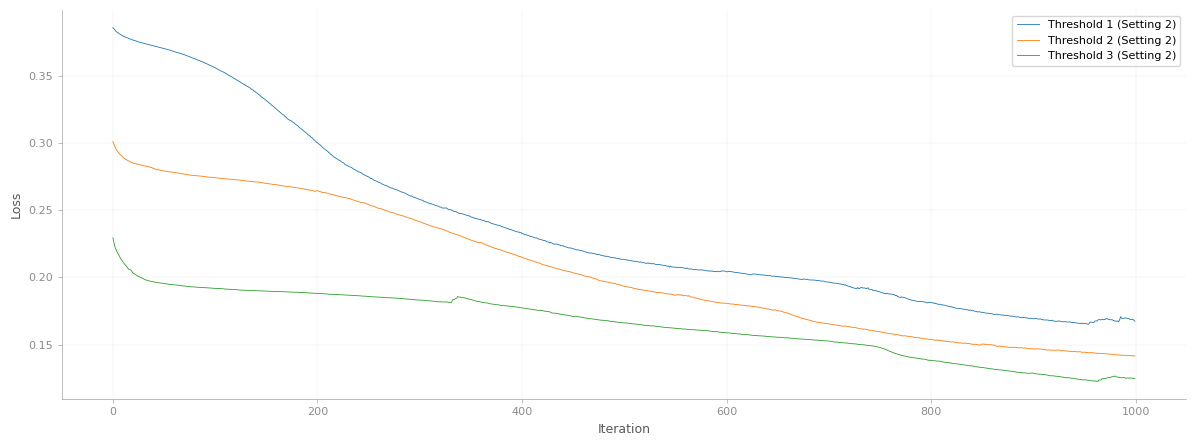

In [23]:
# 1. Group your directories into a list
gan_directories = [gan_data_dir_1, gan_data_dir_2, gan_data_dir_3]

# 2. (Optional) Create clean labels for your subplots
plot_labels = ["Threshold 1 (Setting 2)", "Threshold 2 (Setting 2)", "Threshold 3 (Setting 2)"]

# 3. Call the function
plot_combined_histories(
    dir_paths=gan_directories, 
    labels=plot_labels, 
    figsize=(12, 4.5)  # Optionally change the size here
)

## Initialize postprocessing class

In [32]:
validators = []

run_configs = [("Run 1","Model 5.1 - th 1",output_dir_1, gan_data_dir_1),
               ("Run 2","Model 5.1 - th 2",output_dir_2, gan_data_dir_2),
               ("Run 3","Model 5.1 - th 5",output_dir_3, gan_data_dir_3),
               #("Run 4","Model 5.1 - th all",output_dir_all, gan_data_dir_all)
               #("model 1: 25 epochs", "Standard model", output_dir_gan_01, gan_data_dir_01)
               ]

for gan_name, gan_description, out_dir, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=real_data_dir,
        gan_path=gan_path
    )
    
    # 2. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 2 samples (limit: 100)...
Loaded 100 Run 2 samples into memory.
Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 3 samples (limit: 100)...
Loaded 100 Run 3 samples into memory.



--- Generating 3D PyVista Plot (Run 1 | Mode: COMBINED) ---


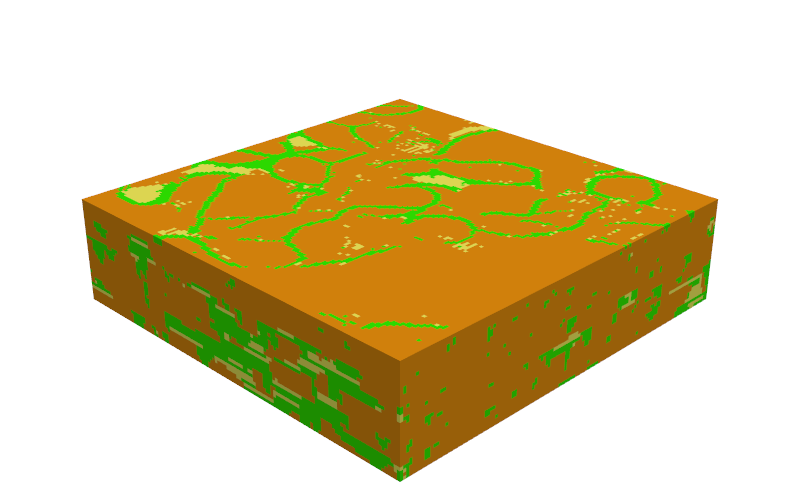

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th1\3d_plot_gan_sample_48combined.png

--- Generating 3D PyVista Plot (Run 2 | Mode: COMBINED) ---


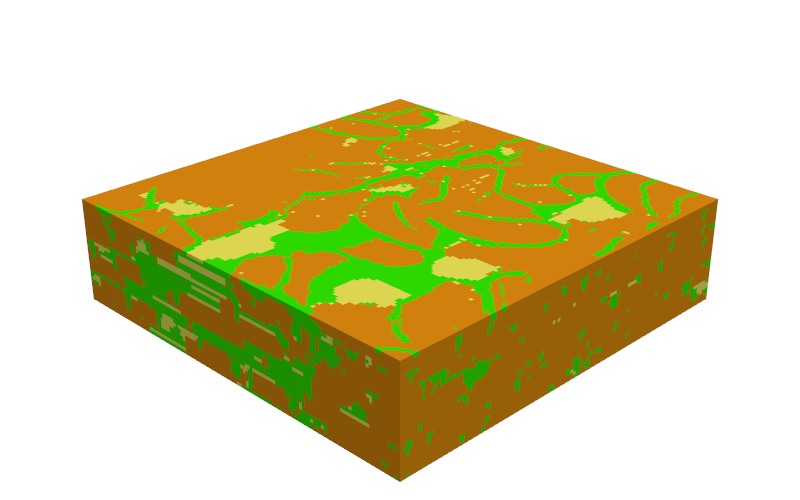

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th2\3d_plot_gan_sample_84combined.png

--- Generating 3D PyVista Plot (Run 3 | Mode: COMBINED) ---


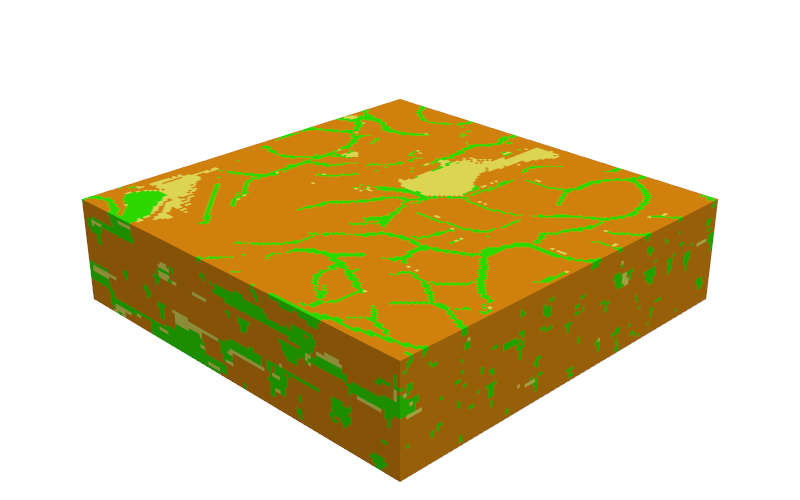

Saved 3D plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\100_epochs_3_classes_cgan_lr_gen_1e3_disc_3e3_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2_th5\3d_plot_gan_sample_77combined.png


In [33]:
for i, validator in enumerate(validators):
    validator.plot_3d_pyvista(mode='combined', show_legend=False)

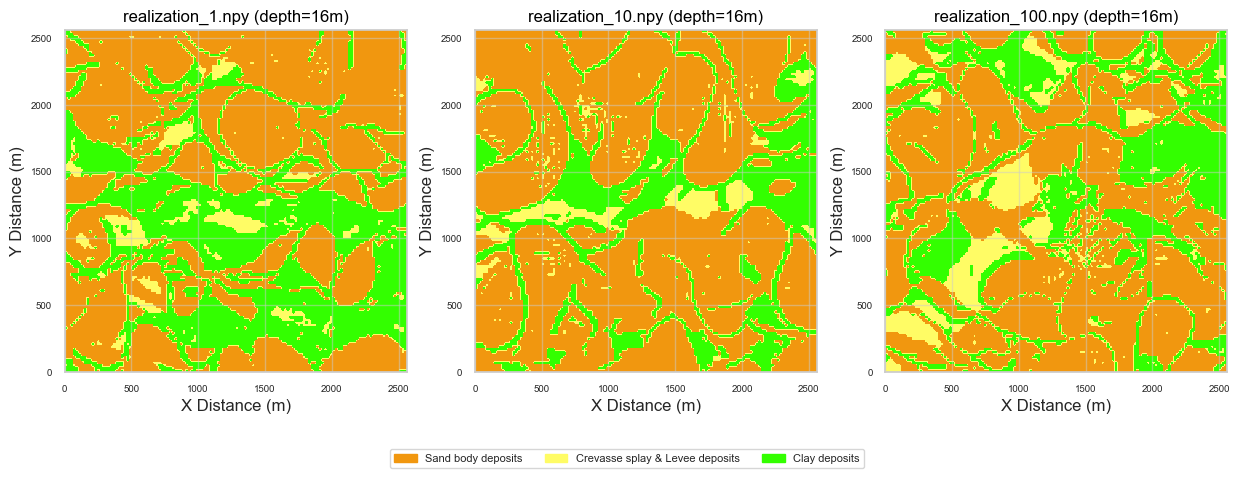

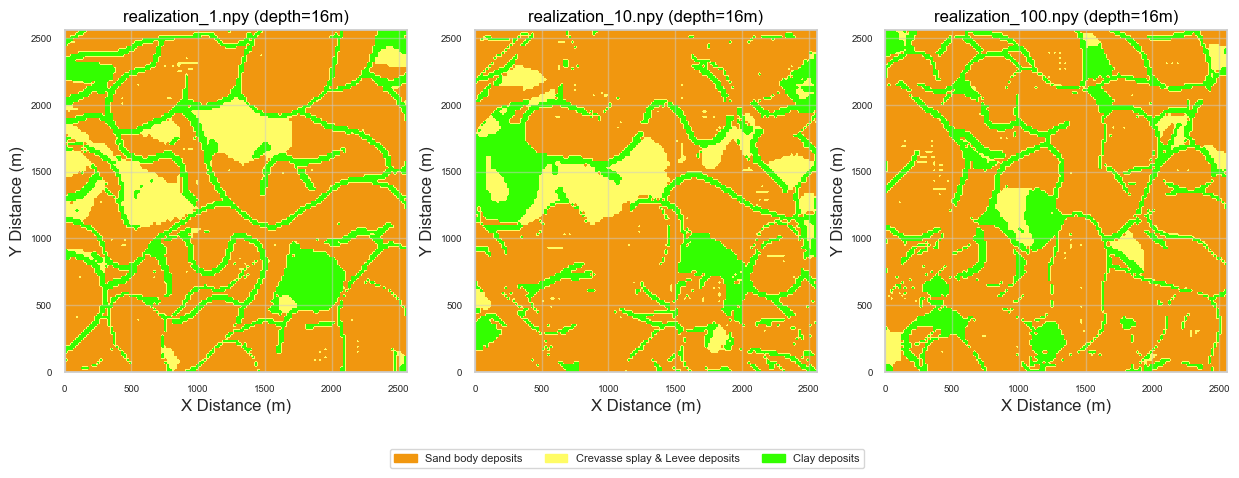

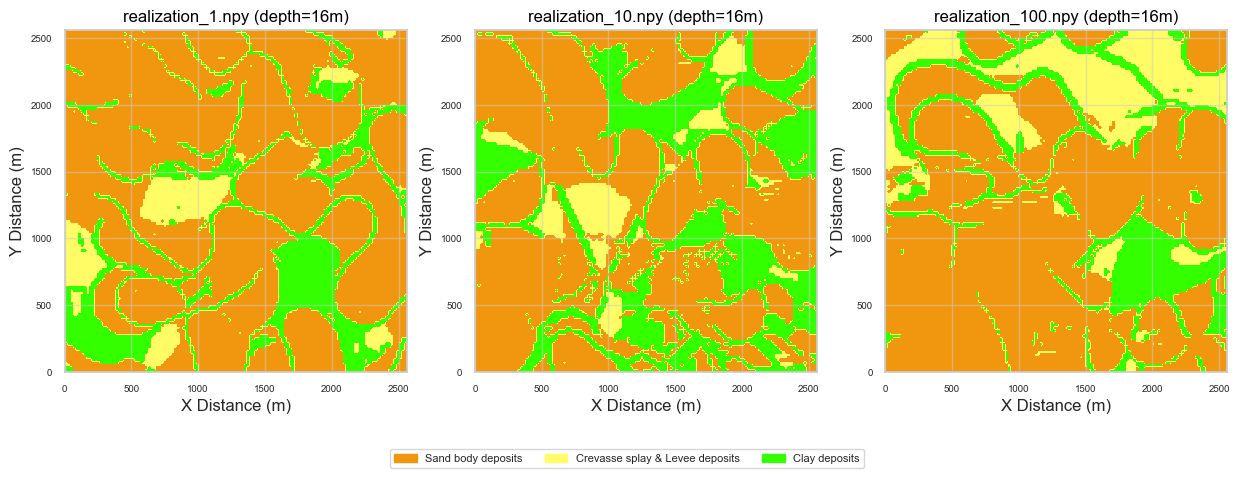

In [34]:
for i, validator in enumerate(validators):
    # if i ==0:
    #     validator.plot_2d_slices(data_source='flumy', num_samples=3, slice_indices=[16])
    # validator.plot_facies_percentages(mode='both')
    validator.plot_2d_slices(axis='Z',num_samples=3, slice_indices=[16])


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


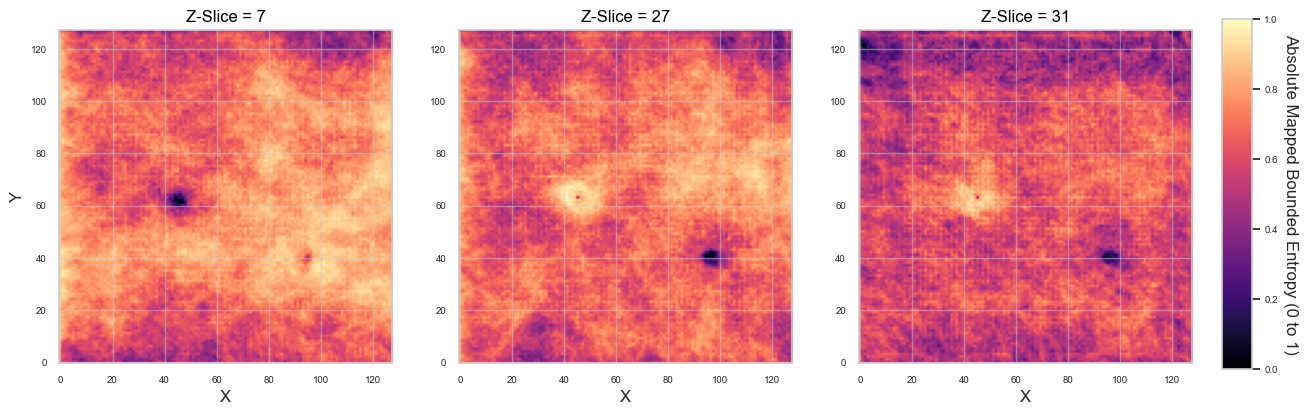

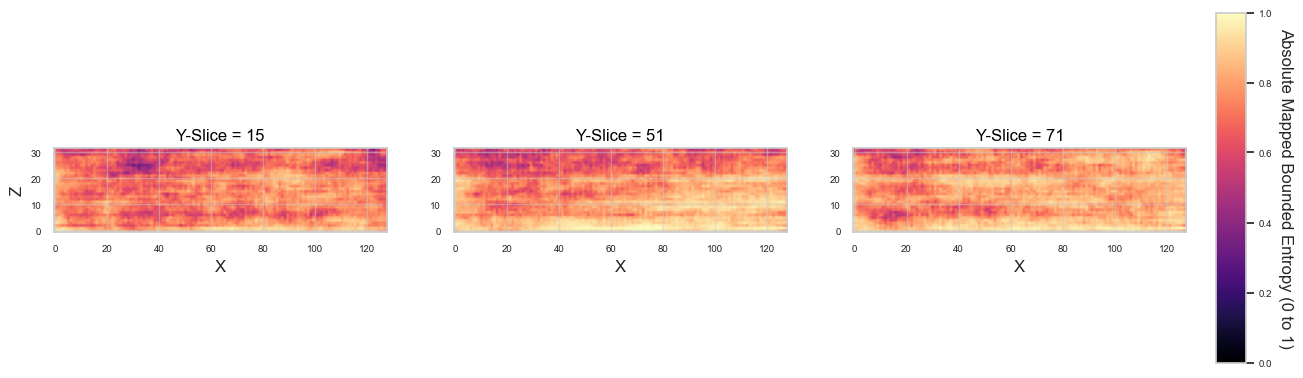

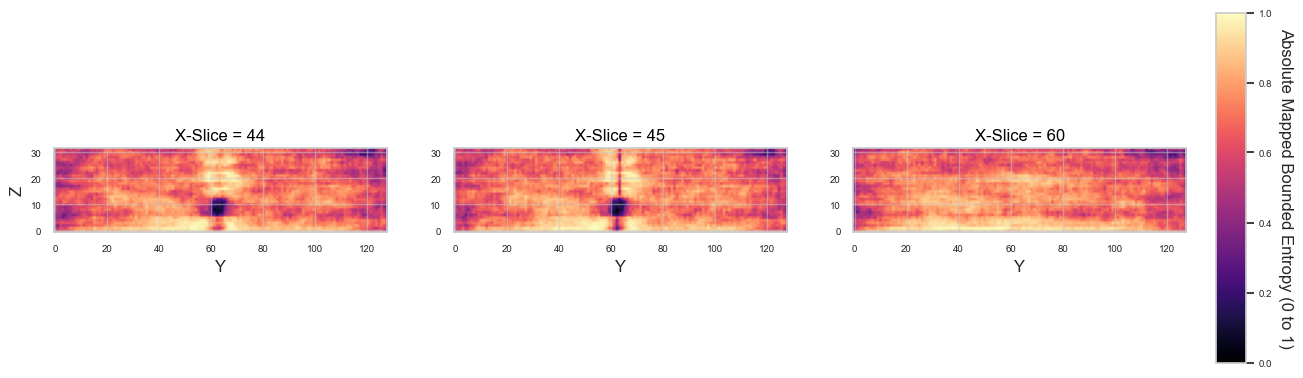


--- Generating 3D PyVista Entropy Map (Run 1) ---
[Run 1] Calculated Mean Voxel-Wise Entropy: 0.7137


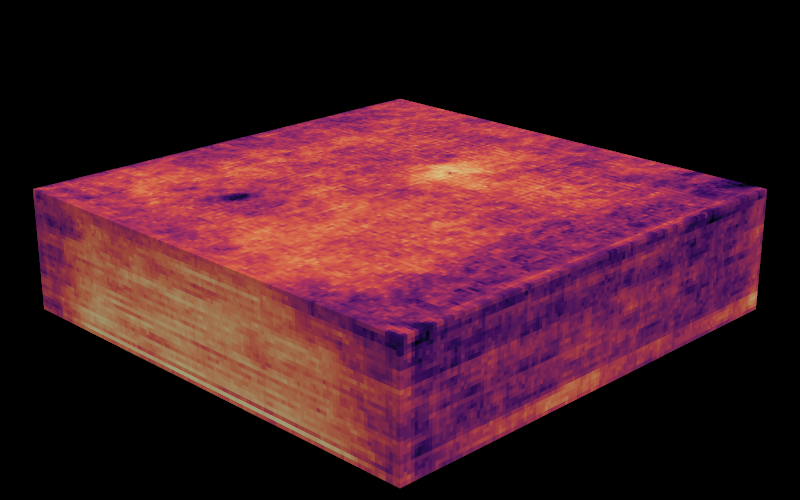


--- Generating Run 2 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


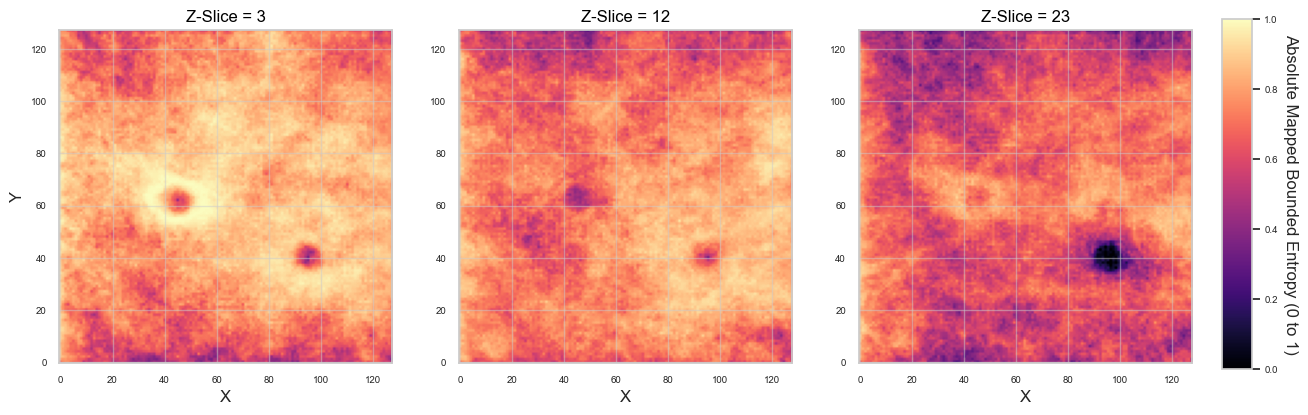

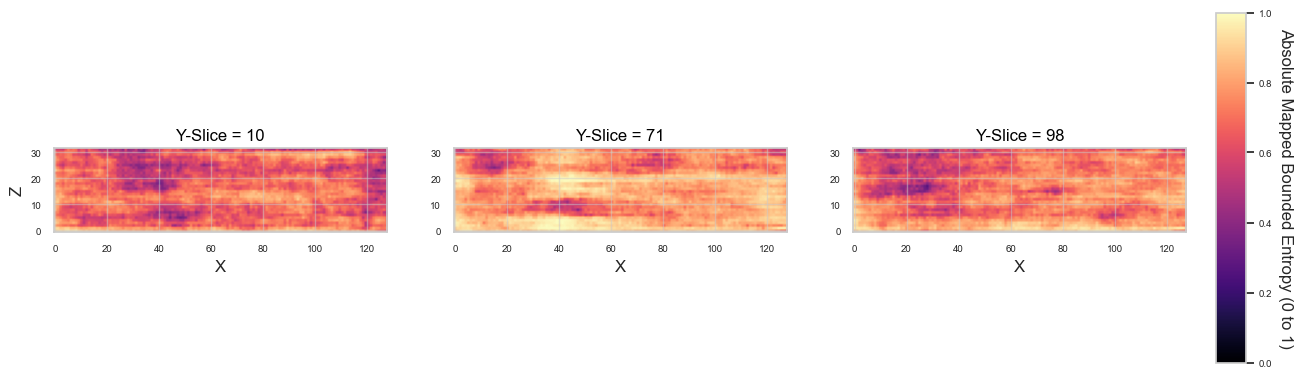

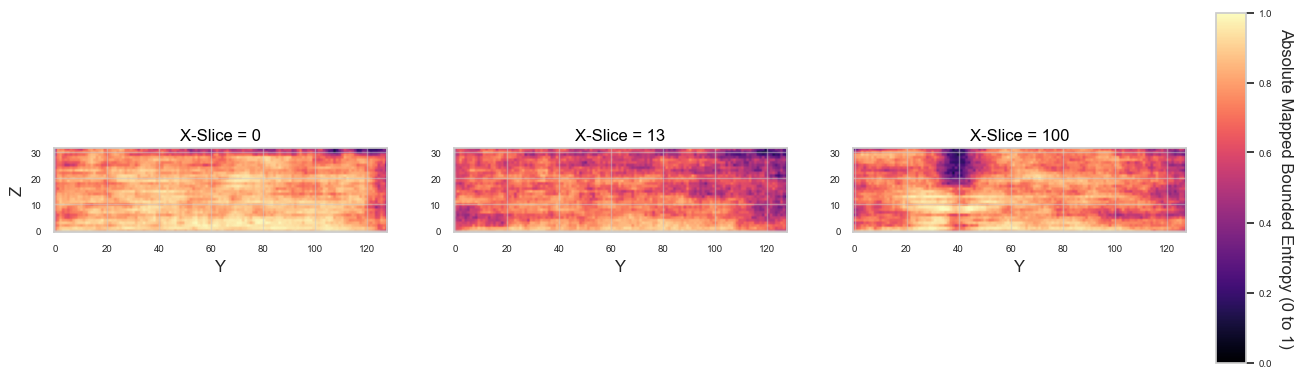


--- Generating 3D PyVista Entropy Map (Run 2) ---
[Run 2] Calculated Mean Voxel-Wise Entropy: 0.7021


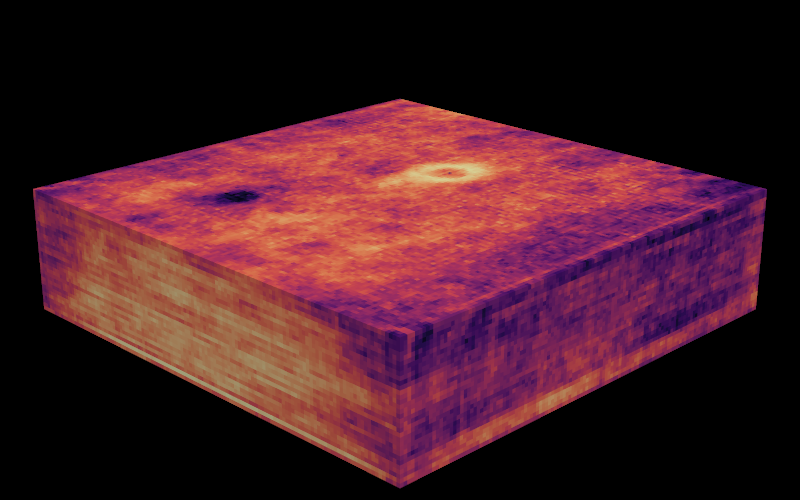


--- Generating Run 3 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 1.5850 bits


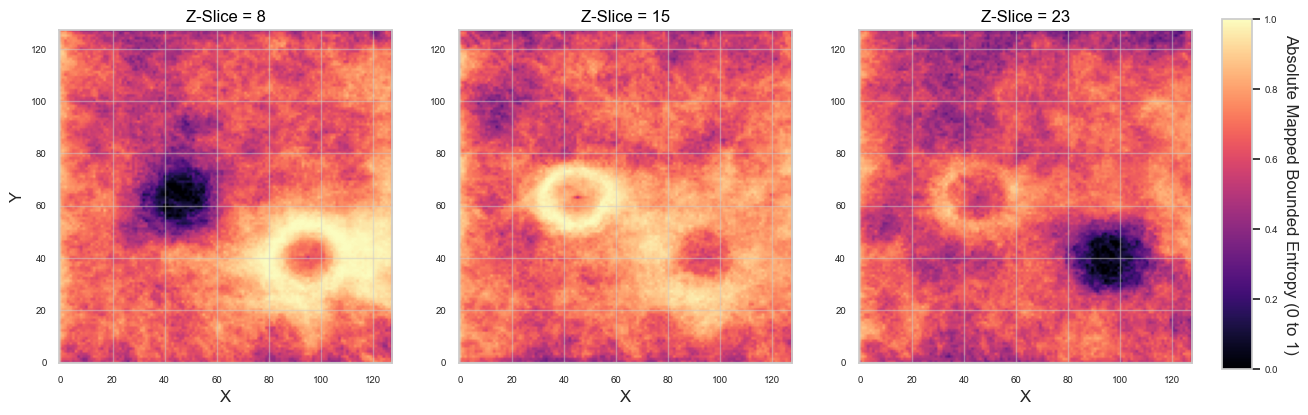

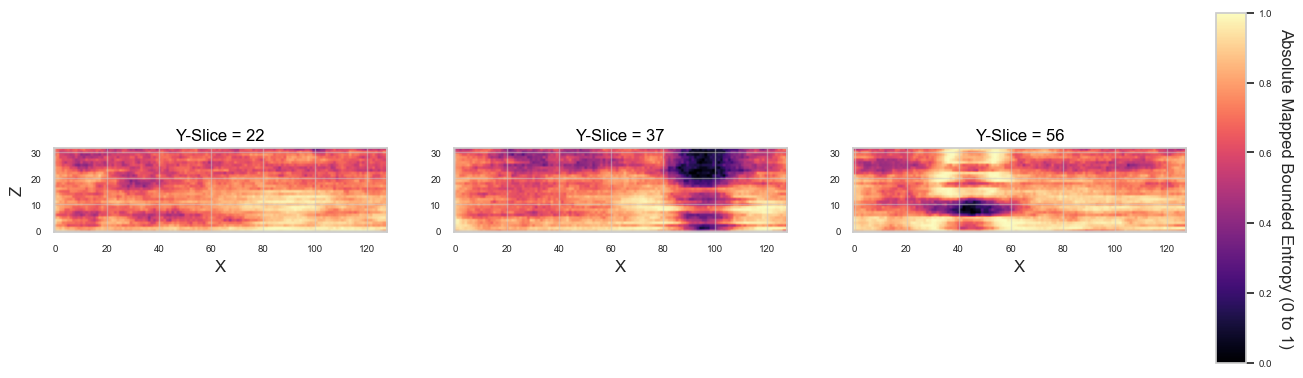

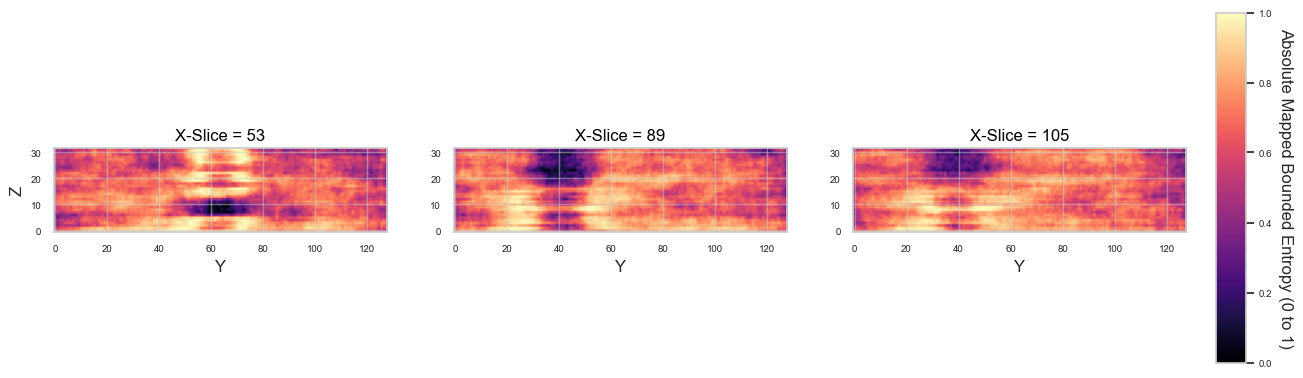


--- Generating 3D PyVista Entropy Map (Run 3) ---
[Run 3] Calculated Mean Voxel-Wise Entropy: 0.6706


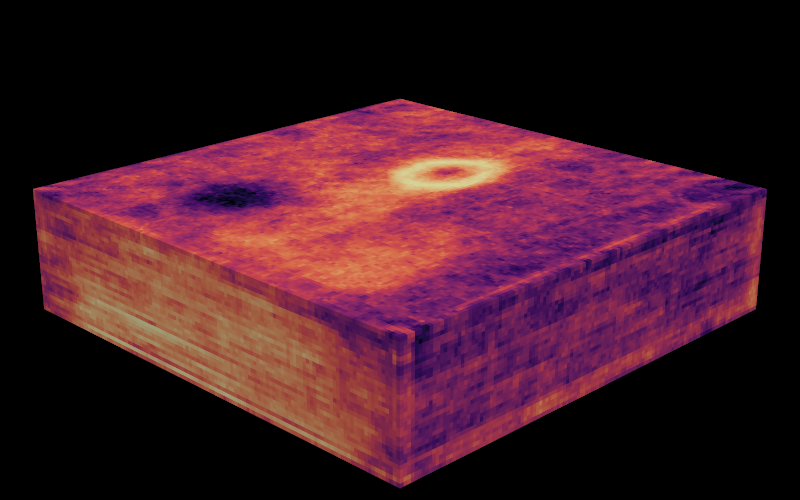

In [35]:
for i, validator in enumerate(validators):
    validator.plot_entropy(num_slices= 3,plot_title=False)
    validator.plot_3d_entropy_pyvista(show_legend= False)


--- Computing Scalar Metrics comparing Run 1 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0128
Run 1 Model Entropy:  0.7137 ± 0.0693
Model-to-Baseline Spatial Entropy Ratio: 1.0405
Model-to-baseline JSD: 0.0168 ± 0.0073

--- Computing Scalar Metrics comparing Run 2 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0128
Run 2 Model Entropy:  0.7021 ± 0.0662
Model-to-Baseline Spatial Entropy Ratio: 1.0235
Model-to-baseline JSD: 0.0181 ± 0.0066

--- Computing Scalar Metrics comparing Run 3 to Baseline across Z-Axis ---

--- Summary Statistics (Z-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0128
Run 3 Model Entropy:  0.6706 ± 0.0703
Model-to-Baseline Spatial Entropy Ratio: 0.9777
Model-to-baseline JSD: 0.0290 ± 0.0085


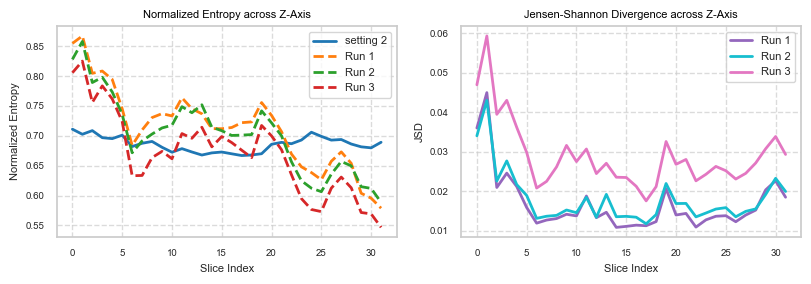


--- Computing Scalar Metrics comparing Run 1 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0442
Run 1 Model Entropy:  0.7137 ± 0.0343
Model-to-Baseline Spatial Entropy Ratio: 1.0405
Model-to-baseline JSD: 0.0168 ± 0.0029

--- Computing Scalar Metrics comparing Run 2 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0442
Run 2 Model Entropy:  0.7021 ± 0.0381
Model-to-Baseline Spatial Entropy Ratio: 1.0235
Model-to-baseline JSD: 0.0181 ± 0.0061

--- Computing Scalar Metrics comparing Run 3 to Baseline across X-Axis ---

--- Summary Statistics (X-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0442
Run 3 Model Entropy:  0.6706 ± 0.0395
Model-to-Baseline Spatial Entropy Ratio: 0.9777
Model-to-baseline JSD: 0.0290 ± 0.0161


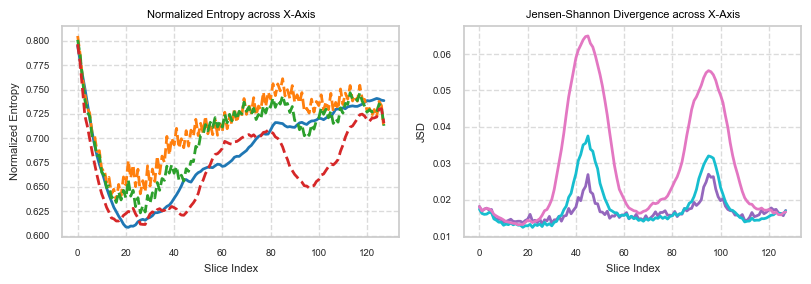


--- Computing Scalar Metrics comparing Run 1 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0405
Run 1 Model Entropy:  0.7137 ± 0.0760
Model-to-Baseline Spatial Entropy Ratio: 1.0405
Model-to-baseline JSD: 0.0168 ± 0.0051

--- Computing Scalar Metrics comparing Run 2 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0405
Run 2 Model Entropy:  0.7021 ± 0.0728
Model-to-Baseline Spatial Entropy Ratio: 1.0235
Model-to-baseline JSD: 0.0181 ± 0.0082

--- Computing Scalar Metrics comparing Run 3 to Baseline across Y-Axis ---

--- Summary Statistics (Y-Axis) ---
Test Baseline Entropy: 0.6859 ± 0.0405
Run 3 Model Entropy:  0.6706 ± 0.0613
Model-to-Baseline Spatial Entropy Ratio: 0.9777
Model-to-baseline JSD: 0.0290 ± 0.0205


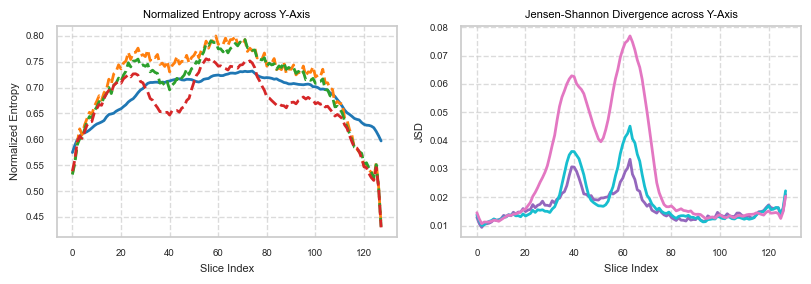

In [38]:
import matplotlib.pyplot as plt

axes_to_plot = ['Z', 'X', 'Y']

for i, axis in enumerate(axes_to_plot):
    fig, fig_axes = plt.subplots(1, 2, figsize=(8.27, 3))
    
    baseline_plotted = False
    gan_colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:brown']
    jsd_colors = ['tab:purple', 'tab:cyan', 'tab:pink', 'tab:olive']
    
    for idx, validator in enumerate(validators):
        df_results, _ = validator.compute_slice_metrics(axis=axis, plot=False)
        
        slices = df_results['Slice_Index']
        flumy_entropy = df_results['Flumy_Norm_Entropy']
        gan_entropy = df_results['GAN_Norm_Entropy']
        jsd = df_results['JSD_Flumy_vs_GAN']
        
        if not baseline_plotted:
            fig_axes[0].plot(slices, flumy_entropy, label=validator.flumy_name, color='tab:blue', linewidth=2)
            baseline_plotted = True
            
        g_color = gan_colors[idx % len(gan_colors)]
        fig_axes[0].plot(slices, gan_entropy, label=f'{validator.gan_name}', color=g_color, linewidth=2, linestyle='--')
        
        j_color = jsd_colors[idx % len(jsd_colors)]
        fig_axes[1].plot(slices, jsd, label=f'{validator.gan_name}', color=j_color, linewidth=2)
        
    fig_axes[0].set_title(f'Normalized Entropy across {axis}-Axis', fontsize=8)
    fig_axes[0].set_xlabel('Slice Index', fontsize=8)
    fig_axes[0].set_ylabel('Normalized Entropy', fontsize=8)
    if i ==0:
        fig_axes[0].legend(fontsize=8)
    fig_axes[0].grid(True, linestyle='--', alpha=0.7)
    
    fig_axes[1].set_title(f'Jensen-Shannon Divergence across {axis}-Axis', fontsize=8)
    fig_axes[1].set_xlabel('Slice Index', fontsize=8)
    fig_axes[1].set_ylabel('JSD', fontsize=8)
    if i == 0:
        fig_axes[1].legend(fontsize=8)
    fig_axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'combined_H_and_JSD_metrics_axis_{axis}.png', dpi=600)
    plt.show()


Processing Well Mismatch for Run 1...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.8847
Average F1 Class 1 (Channel): 0.8989
Average F1 Class 2 (Levee): 0.8665
Average F1 Class 3 (Overbank): 0.8888
-> Generating trajectory cross-sections for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 1\well_trajectory_DEL-GT-01_1samples.png


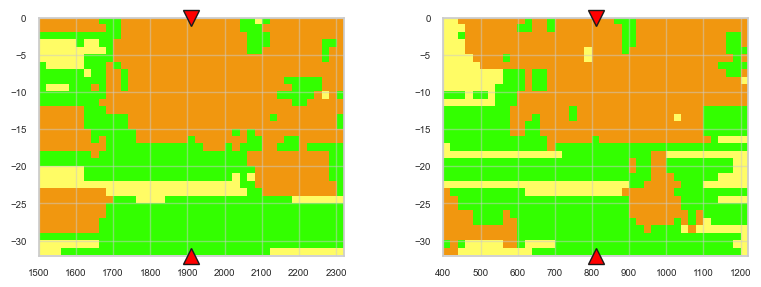


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 1) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 1\well_entropy_DEL-GT-01_Run_1.png


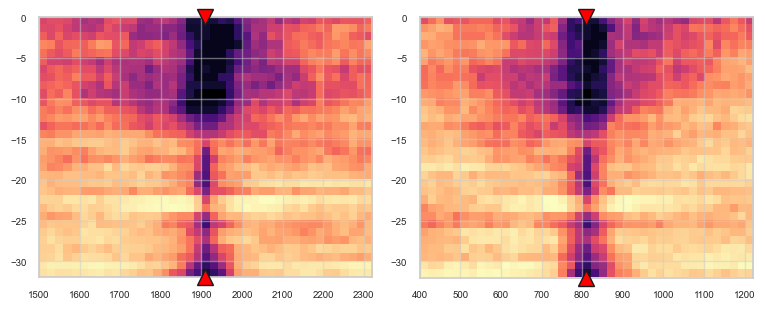

-> Generating trajectory cross-sections for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 1\well_trajectory_DEL-GT-02-S2_1samples.png


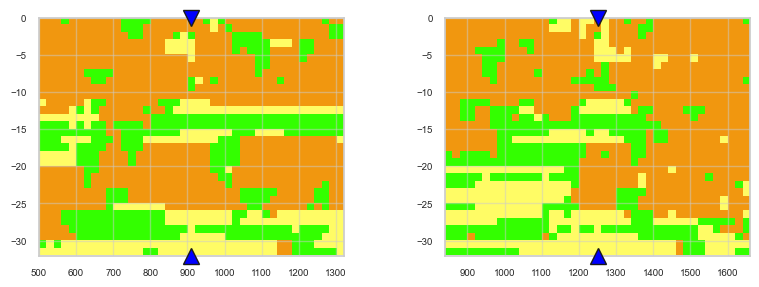


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 1) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 1\well_entropy_DEL-GT-02-S2_Run_1.png


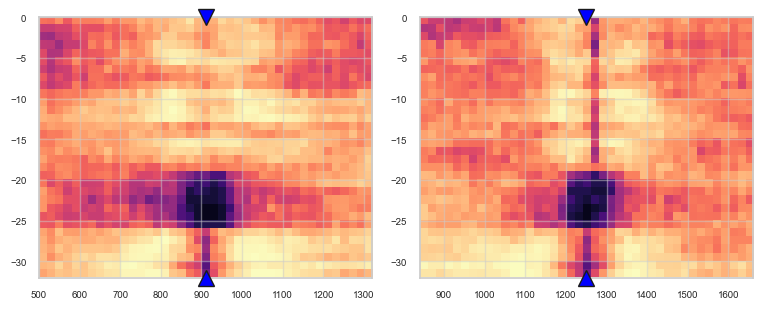


Processing Well Mismatch for Run 2...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.8985
Average F1 Class 1 (Channel): 0.9183
Average F1 Class 2 (Levee): 0.8884
Average F1 Class 3 (Overbank): 0.8889
-> Generating trajectory cross-sections for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 2\well_trajectory_DEL-GT-01_1samples.png


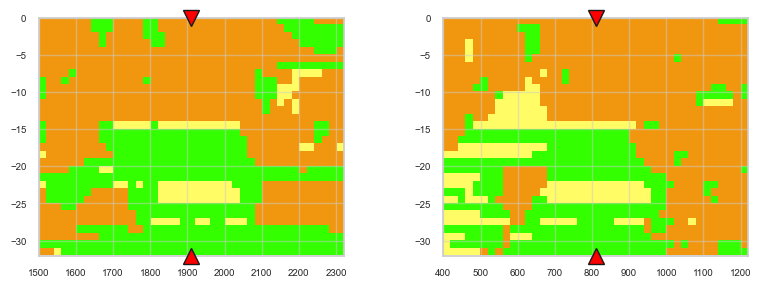


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 2) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 2\well_entropy_DEL-GT-01_Run_2.png


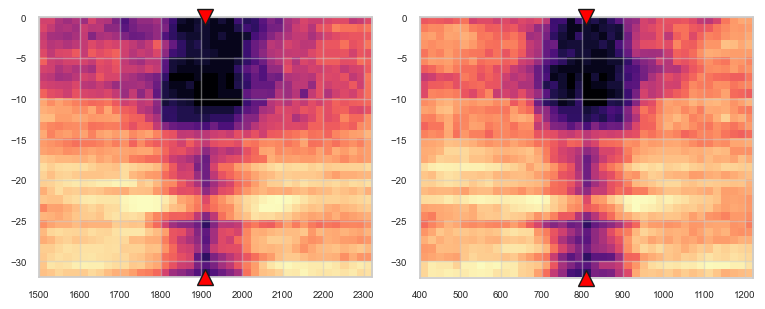

-> Generating trajectory cross-sections for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 2\well_trajectory_DEL-GT-02-S2_1samples.png


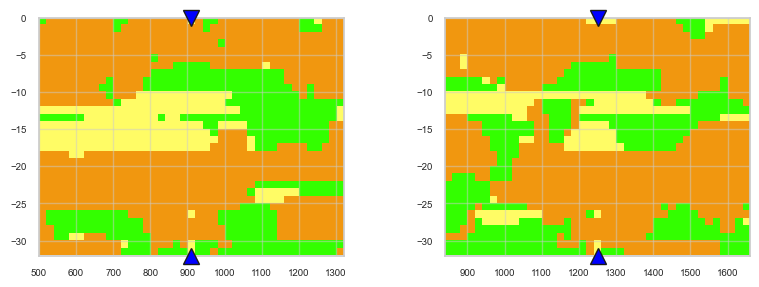


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 2) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 2\well_entropy_DEL-GT-02-S2_Run_2.png


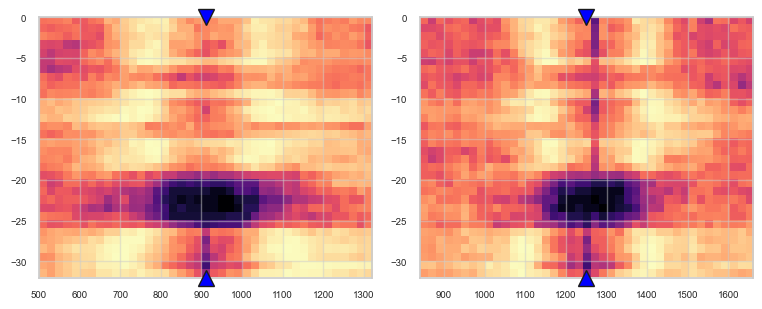


Processing Well Mismatch for Run 3...
Loaded 64 well conditioning points.

--- Well Data Mismatch ---
Evaluated 100 realizations.
Average Macro F1 Score: 0.9144
Average F1 Class 1 (Channel): 0.9359
Average F1 Class 2 (Levee): 0.8982
Average F1 Class 3 (Overbank): 0.9091
-> Generating trajectory cross-sections for Well: DEL-GT-01...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 3\well_trajectory_DEL-GT-01_1samples.png


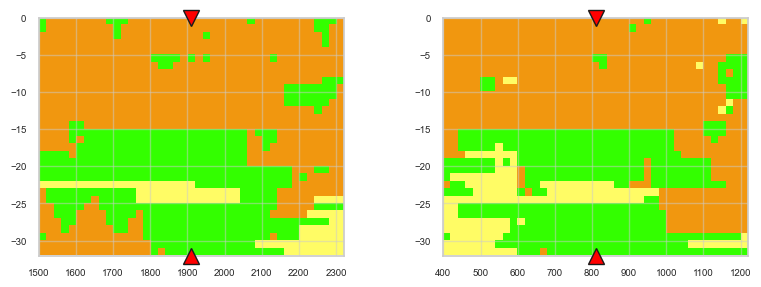


--- Generating Normalized Entropy Slices for Well: DEL-GT-01 (Run 3) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 3\well_entropy_DEL-GT-01_Run_3.png


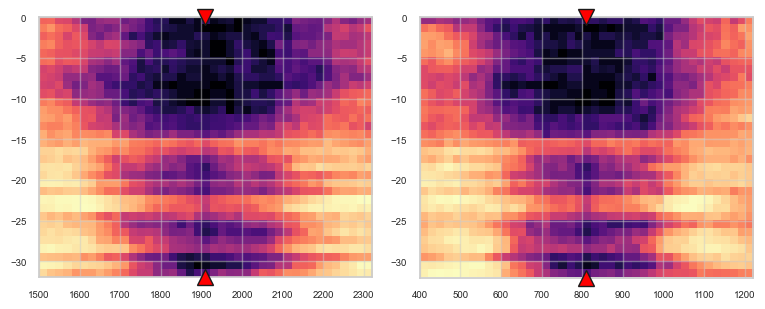

-> Generating trajectory cross-sections for Well: DEL-GT-02-S2...
Saved well trajectory slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 3\well_trajectory_DEL-GT-02-S2_1samples.png


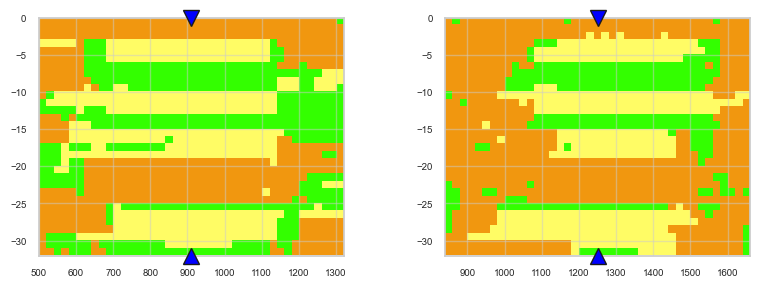


--- Generating Normalized Entropy Slices for Well: DEL-GT-02-S2 (Run 3) ---
Saved well entropy slices to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\Run 3\well_entropy_DEL-GT-02-S2_Run_3.png


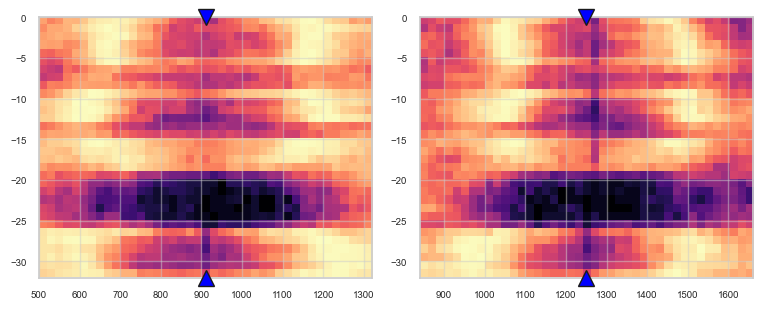


--- Generating Comparative Summary Plots ---
Saved global F1 distributions to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\f1_score_comparisons.png
Mean accuracy score of DEL-GT-01: 0.94


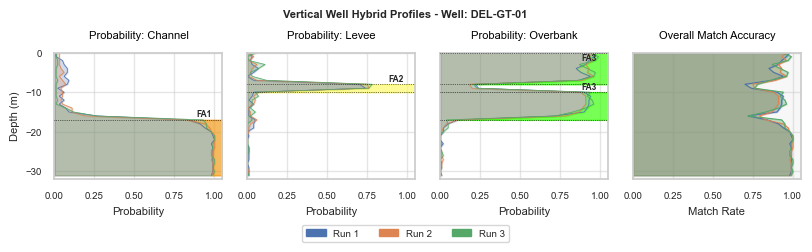

Mean accuracy score of DEL-GT-02-S2: 0.89


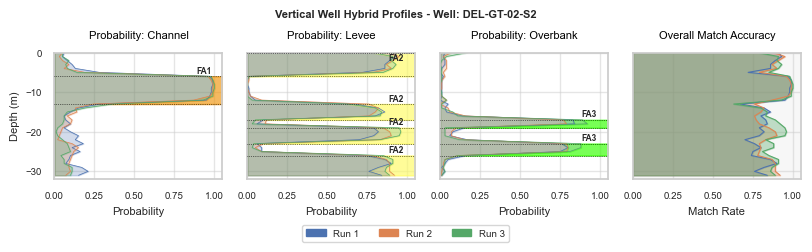

Saved depth-dependent accuracy profiles to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\accuracy_score_across_depth.png

All mismatch evaluations and visualizations completed successfully!


In [41]:
run_configs = [
    ("Run 1", gan_data_dir_1),
    ("Run 2", gan_data_dir_2),
    ("Run 3", gan_data_dir_3),
    #("Run all", gan_data_dir_all)
]

well_validators = []
f1_scores_results = {}

for gan_name, gan_path in run_configs:
    print(f"\n=========================================")
    print(f"Processing Well Mismatch for {gan_name}...")
    print(f"=========================================")
    
    # Initialize the validator for the current GAN run
    validator = WellMismatch(
        flumy_name='setting 2',
        gan_name=gan_name, 
        data_dir=gan_path,          
        well_data_path=well_data_path
    )
    
    # Compute the overall and per-class F1 mismatch dataframe
    df_f1_scores = validator.compute_mismatch()
    
    # Store for global comparison later
    well_validators.append(validator)
    f1_scores_results[gan_name] = df_f1_scores

    # Extract unique well names loaded from the spreadsheet tabs
    unique_wells = sorted(list(set(validator.well_names)))
    
    for actual_well in unique_wells:
        print(f"-> Generating trajectory cross-sections for Well: {actual_well}...")
        
        run_output_dir = os.path.join(output_dir_2.parent, 'trajectory_slices', gan_name)
        
        # 1. Plot Categorical Facies Slice
        validator.plot_well_trajectory_slices(
            well_name=actual_well,
            figsize=(8.27,3),
            plot_title=False, 
            plot_suptitle=False, 
            plot_axtitle=False,
            slice_range=20,
            num_samples=1,          
            show_plot=True,         
            save_plot=True,         
            output_dir=run_output_dir,
            show_legend=False
        )

        # 2. Plot Entropy Slice (Argument updated!)
        validator.plot_well_trajectory_entropy_slices(
            well_name=actual_well,
            figsize=(8.27,3.5),
            plot_title=False, 
            plot_suptitle=False, 
            plot_axtitle=False,
            slice_range=20,
            show_plot=True,         
            save_plot=True,         
            output_dir=run_output_dir,
            show_legend=False
        )

    # Global compilation block triggered ONLY at the end of the final run ("Run all")
    if gan_name == "Run 3":
        print(f"\n--- Generating Comparative Summary Plots ---")
        validators_dict = dict(zip([cfg[0] for cfg in run_configs], well_validators))

        # 1. Plot and save comparative histogram distributions
        f1_save_path = os.path.join(output_dir_2.parent, 'f1_score_comparisons.png')
        # validator.plot_comparative_f1_distributions(
        #     f1_scores_results, 
        #     validators_dict, 
        #     save_path=f1_save_path
        # )
        print(f"Saved global F1 distributions to: {f1_save_path}")
        
        # 2. Plot and save vertical depth-dependent profile match rates
        well_accuracy_path = os.path.join(output_dir_2.parent, 'accuracy_score_across_depth.png')
        validator.plot_hybrid_well_profile(
            validators_dict, 
            save_path=well_accuracy_path
        )
        print(f"Saved depth-dependent accuracy profiles to: {well_accuracy_path}")

print("\nAll mismatch evaluations and visualizations completed successfully!")

## **Figure 4.11**

Master combined plot successfully saved to:
C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices\master_grouped_facies_and_entropy.png


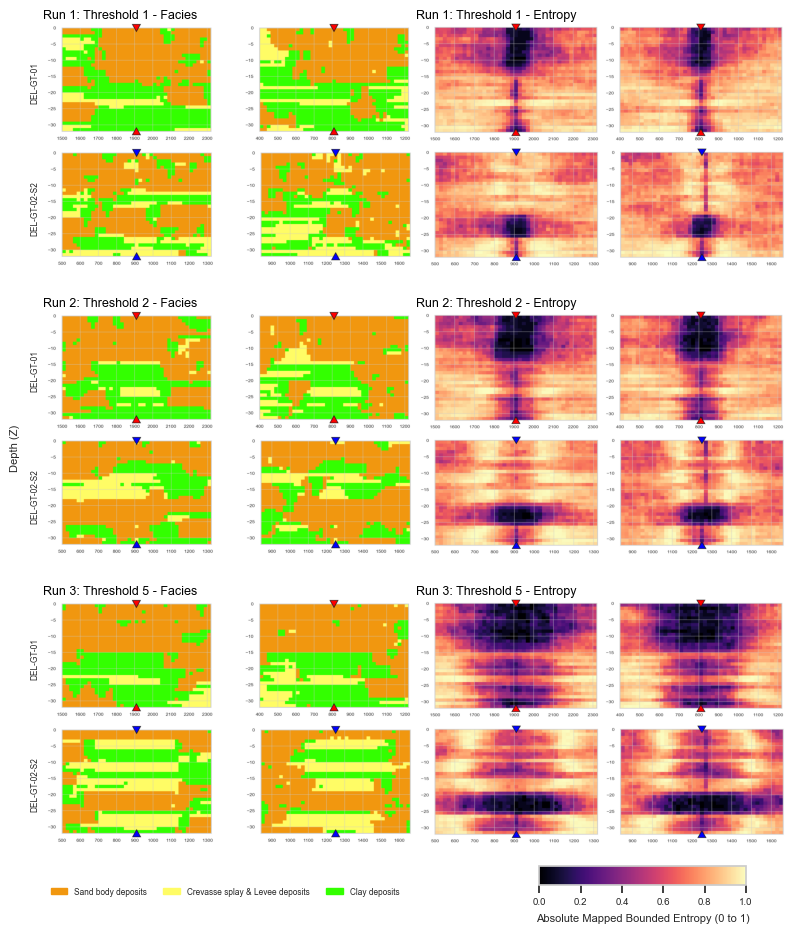

In [37]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# --- Base Directories and Configurations ---
base_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\trajectory_slices"

dir_1 = os.path.join(base_dir, "Run 1")
dir_2 = os.path.join(base_dir, "Run 2")
dir_3 = os.path.join(base_dir, "Run 3")

names = [
    "Run 1: Threshold 1",
    "Run 2: Threshold 2",
    "Run 3: Threshold 5"
]

model_groups = [
    {
        "name": names[0],
        "well_1_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_1, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-01_Run_1.png"),
        "well_2_entropy": os.path.join(dir_1, "well_entropy_DEL-GT-02-S2_Run_1.png")
    },
    {
        "name": names[1],
        "well_1_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_2, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-01_Run_2.png"),
        "well_2_entropy": os.path.join(dir_2, "well_entropy_DEL-GT-02-S2_Run_2.png")
    },
    {
        "name": names[2],
        "well_1_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-01_1samples.png"),
        "well_2_facies": os.path.join(dir_3, "well_trajectory_DEL-GT-02-S2_1samples.png"),
        "well_1_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-01_Run_3.png"),
        "well_2_entropy": os.path.join(dir_3, "well_entropy_DEL-GT-02-S2_Run_3.png")
    }
]

legend_config = {
    'names': {
        1: 'Sand body deposits',
        4: 'Crevasse splay & Levee deposits',
        8: 'Clay deposits'
    },
    'colors': {
        1: '#f1970f',
        4: '#fffc65',
        8: '#33ff00'
    }
}

# --- Plotting Function ---
def plot_combined_gridspec(groups, facies_legend, plot_size=(8.27, 9.5)):
    fig = plt.figure(figsize=plot_size)
    
    # Reduced outer hspace from 0.3 to 0.15
    outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.15)

    for i, group in enumerate(groups):
        inner_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[i], hspace=0.008, wspace=0.005)
        
        # NEW: Added row_label parameter to handle well names dynamically
        def add_image(ax, img_path, title=None, row_label=None):
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                # Added aspect='auto' to force the image to fill the grid cell completely
                ax.imshow(img, aspect='auto')
            else:
                ax.text(0.5, 0.5, f"Missing:\n{os.path.basename(img_path)}", 
                        ha='center', va='center', color='red', fontsize=6)
            
            ax.axis('off')
            
            if title:
                ax.set_title(title, loc='left', fontsize=9, pad=1)
                
            # NEW: Attach the well name label vertically to the left edge of the plot
            if row_label:
                ax.text(-0.01, 0.5, row_label, transform=ax.transAxes, 
                        rotation=90, va='center', ha='right', fontsize=6)

        # --- Column 0: Facies ---
        # Pass the row_labels ONLY to the first column (Facies) so they act as row headers
        ax_facies_w1 = fig.add_subplot(inner_gs[0, 0])
        add_image(ax_facies_w1, group["well_1_facies"], title=f"{group['name']} - Facies", row_label="DEL-GT-01")
        
        ax_facies_w2 = fig.add_subplot(inner_gs[1, 0])
        add_image(ax_facies_w2, group["well_2_facies"], row_label="DEL-GT-02-S2")

        # --- Column 1: Entropy ---
        ax_entropy_w1 = fig.add_subplot(inner_gs[0, 1])
        add_image(ax_entropy_w1, group["well_1_entropy"], title=f"{group['name']} - Entropy")
        
        ax_entropy_w2 = fig.add_subplot(inner_gs[1, 1])
        add_image(ax_entropy_w2, group["well_2_entropy"])


    # NEW: Added a shared global Y-axis title for Depth
    fig.supylabel("Depth (Z)", fontsize=8, x=0.01)

    # UPDATED: Increased left margin (from 0.05 to 0.1) to accommodate the new row labels and Z-axis title
    fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.08)

    # --- Add Global Legends ---
    legend_patches = [mpatches.Patch(color=facies_legend['colors'][key], label=facies_legend['names'][key]) 
                      for key in facies_legend['names']]
    
    fig.legend(
        handles=legend_patches, 
        loc='lower left', 
        ncol=3, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=6,
        bbox_to_anchor=(0.05, 0.02) # Snug to the updated left margin
    )

    cbar_ax = fig.add_axes([0.65, 0.04, 0.25, 0.02]) 
    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
    sm.set_array([]) 

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Absolute Mapped Bounded Entropy (0 to 1)', fontsize=8, labelpad=5)
    cbar.ax.tick_params(labelsize=7)

    output_path = os.path.join(base_dir, "master_grouped_facies_and_entropy.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Master combined plot successfully saved to:\n{output_path}")

    plt.show()

plot_combined_gridspec(model_groups, legend_config)